# **DS3040 Introduction to Deep Learning**

In [1]:
import os
import copy
import math
import random
from typing import Dict, List, Tuple
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

In [6]:
tf = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,),(0.5,))])

train_data = datasets.FashionMNIST(root='', train=True,download=False, transform=tf)
test_data = datasets.FashionMNIST(root='',train=False, download=False,transform=tf)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)
results={}

In [41]:
def evaluate(model: nn.Module, loader: DataLoader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            _, preds = torch.max(outputs, 1)

            correct += (preds == y).sum().item()
            total += y.size(0)
    return 100 * correct / total


def train_model(model: nn.Module, epochs=4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    accuracy_history = []
    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
        acc = evaluate(model, test_loader)
        accuracy_history.append(acc)
        print(f"Epoch {epoch+1}/{epochs} | Test Accuracy: {acc:.2f}%")
    return (accuracy_history, accuracy_history[-1])

def plot_accuracy(name, history):
    plt.figure()
    plt.plot(history, label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Test Accuracy (%)")
    plt.title("Model Accuracy Comparison")
    plt.legend()
    plt.show()

## **1. Basic CNN**

### Implement a Convolutional Neural Network (CNN) using PyTorch on the fashion MNIST dataset

### (a) Load the dataset using torchvision.datasets.mnist.FashionMNIST. Use Subset from torch.utils.data to split into train and test sets.

### b) Build a basic CNN architecture, with 3 convolutional layers and 2 fully connected layers. Each convolutional layer should be followed by a ReLU activation layer and a max pooling layer.

In [40]:
class CNNBase(nn.Module):
    def __init__(self, conv_layers: int, dropout_conv=False, dropout_fc=False):
        super().__init__()
        channels = [1, 32, 64, 128, 256, 512]
        conv_blocks = []
        if conv_layers < 5:
            for i in range(conv_layers):
                conv_blocks.append(nn.Conv2d(channels[i],channels[i+1],3,padding=1))
                conv_blocks.append(nn.ReLU())
                conv_blocks.append(nn.MaxPool2d(2))
                if dropout_conv:
                    conv_blocks.append(nn.Dropout2d(0.25))
        else:
            for i in range(conv_layers):
                conv_blocks.append(nn.Conv2d(channels[i],channels[i+1],3,padding=2))
                conv_blocks.append(nn.ReLU())
                conv_blocks.append(nn.MaxPool2d(2))
                if dropout_conv:
                    conv_blocks.append(nn.Dropout2d(0.25))
                    
        self.conv = nn.Sequential(*conv_blocks)
        size = 28
        if conv_layers<5:
            for _ in range(conv_layers):
                size = size//2
        else:
            size = 2
        fc_input = channels[conv_layers]*size*size
        self.fc1 = nn.Linear(fc_input,128)
        self.dropout_fc = nn.Dropout(0.5) if dropout_fc else None
        self.fc2 = nn.Linear(128,10)
        self.relu = nn.ReLU()
        self.dropout_fc = nn.Dropout(0.5) if dropout_fc else None

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        x = self.relu(self.fc1(x))
        if self.dropout_fc:
            x = self.dropout_fc(x)
        x = self.fc2(x)
        return x

### (c) Train the model on the dataset, and evaluate its performance on the test set. Plot the accuracy curve

In [13]:
print("Training 3-layer CNN")
model_3 = CNNBase(3)
hist3, acc3 = train_model(model_3)
results["CNN-3"] = hist3

Training 3-layer CNN
Epoch 1/5 | Test Accuracy: 87.78%
Epoch 2/5 | Test Accuracy: 89.35%
Epoch 3/5 | Test Accuracy: 90.10%
Epoch 4/5 | Test Accuracy: 90.71%
Epoch 5/5 | Test Accuracy: 90.99%


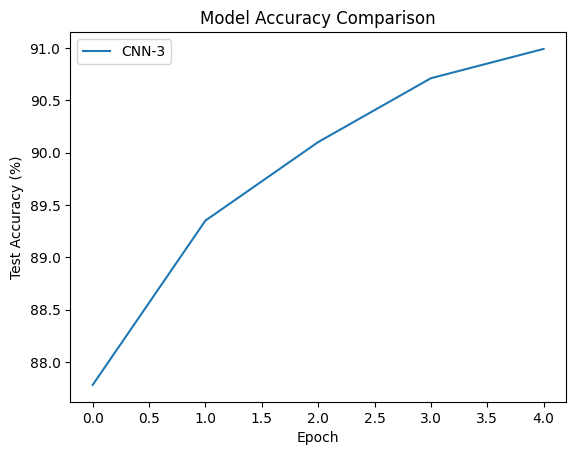

In [15]:
plot_accuracy("CNN-3",hist3)

## **2. Varying the architecture**

## Experiment with different architectures.
### (a) Modify the above architecture to have 2 and 5 convolutional layers respectively, and train these models. Test these models on the test set and compare their accuracies.

In [28]:
print("Training 2-layer CNN")
model_2 = CNNBase(2)
hist2, acc2 = train_model(model_2)
results["CNN-2"] = hist2

Training 2-layer CNN
Epoch 1/5 | Test Accuracy: 88.38%
Epoch 2/5 | Test Accuracy: 89.97%
Epoch 3/5 | Test Accuracy: 90.76%
Epoch 4/5 | Test Accuracy: 90.90%
Epoch 5/5 | Test Accuracy: 91.22%


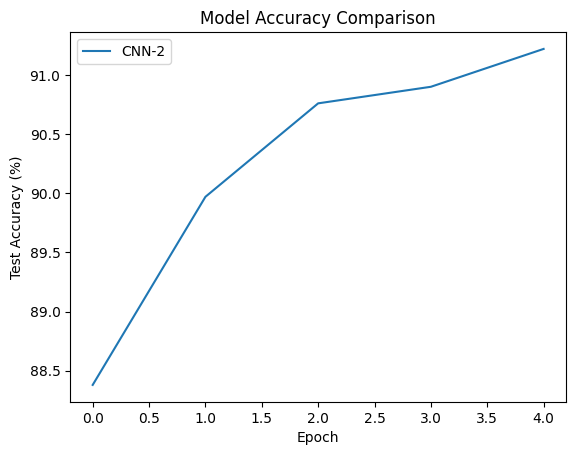

In [29]:
plot_accuracy("CNN-2",hist2)

In [43]:
print("Training 5-layer CNN")
model_5 = CNNBase(5)
hist5, acc5 = train_model(model_5)
results["CNN-5"] = hist5

Training 5-layer CNN
Epoch 1/4 | Test Accuracy: 86.97%
Epoch 2/4 | Test Accuracy: 89.18%
Epoch 3/4 | Test Accuracy: 90.63%
Epoch 4/4 | Test Accuracy: 89.90%


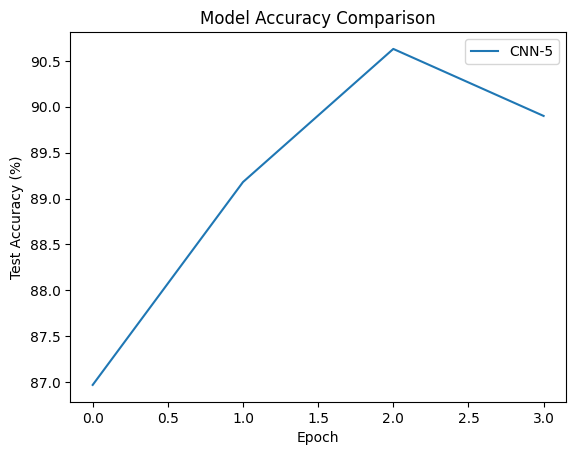

In [44]:
plot_accuracy("CNN-5",hist5)

#### When i did CNN with 2 convolutional layers the network becomes too shallow and so it underfits. So we could see the drop in accuracy. When i ran it with 5 layers, the network becomes too deep so it should overfit as the dataset is small....Can't verify, code has some error :(. When its 3 convolutional layers, it balances the bias and variance and thus it is the best baseline.

### (b) Using the initial architecture with 3 convolutional layers, introduce dropout layers to the architecture in two ways:
- A dropout layer after each convolutional layer
- A dropout layer after each fully connected layer
### Train these models, and report their accuracies on the test set

In [45]:
print("Training Dropout after Conv")
model_drop_conv = CNNBase(3, dropout_conv=True)
hist_dc, acc_dc = train_model(model_drop_conv)
results["Dropout-Conv"] = hist_dc

Training Dropout after Conv
Epoch 1/4 | Test Accuracy: 86.64%
Epoch 2/4 | Test Accuracy: 88.37%
Epoch 3/4 | Test Accuracy: 89.68%
Epoch 4/4 | Test Accuracy: 90.49%


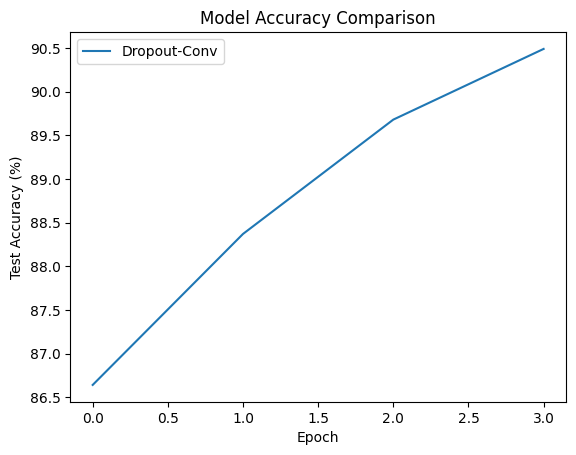

In [46]:
plot_accuracy("Dropout-Conv",hist_dc)

In [47]:
print("Training Dropout after FC")
model_drop_fc = CNNBase(3, dropout_fc=True)
hist_df, acc_df = train_model(model_drop_fc)
results["Dropout-FC"] = hist_df

Training Dropout after FC
Epoch 1/4 | Test Accuracy: 86.70%
Epoch 2/4 | Test Accuracy: 88.72%
Epoch 3/4 | Test Accuracy: 89.29%
Epoch 4/4 | Test Accuracy: 89.76%


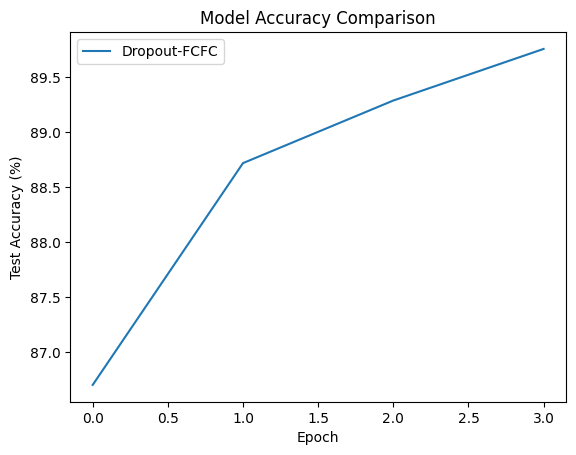

In [48]:
plot_accuracy("Dropout-FCFC",hist_df)

### (c) Using the above results, write your inferences on the effect of introducing dropout layers after convolutional layers and fully connected layers.

#### Dropout in FC layers usually improves generalization the most because dense layers contain the majority of parameters.

## **3. Comparison with SqueezeNet**

### Implement VGG19 from PyTorch and compare with the previously created architecture.

### (a) Load the vgg19 model from torchvision.models. Modify the final layer to output 10 classes instead of the default 1000. Train the model on the given dataset and evaluate its performance on the test set

In [49]:
from torchvision.models import squeezenet1_1

class SqueezeNet(nn.Module):
    def __init__(self, weight_path):
        super().__init__()
        self.model = squeezenet1_1()
        state_dict = torch.load(weight_path)
        self.model.load_state_dict(state_dict)
        for param in self.model.parameters():
            param.requires_grad = False
        self.model.classifier[1] = nn.Conv2d(512, 10, kernel_size=(1,1),stride=(1,1))
        self.model.num_classes = 10
        for param in self.model.classifier.parameters():
            param.requires_grad = True

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)
        return self.model(x)

In [50]:
print("Training SqueezeNet")
squeeze = SqueezeNet("squeezenet_weights.pth")
hist_sq, acc_sq = train_model(squeeze)
results["Squeeze"] = hist_sq

Training SqueezeNet


/tmp/ipykernel_20338/4109355283.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path)


Epoch 1/4 | Test Accuracy: 58.42%
Epoch 2/4 | Test Accuracy: 69.48%
Epoch 3/4 | Test Accuracy: 70.01%
Epoch 4/4 | Test Accuracy: 70.75%


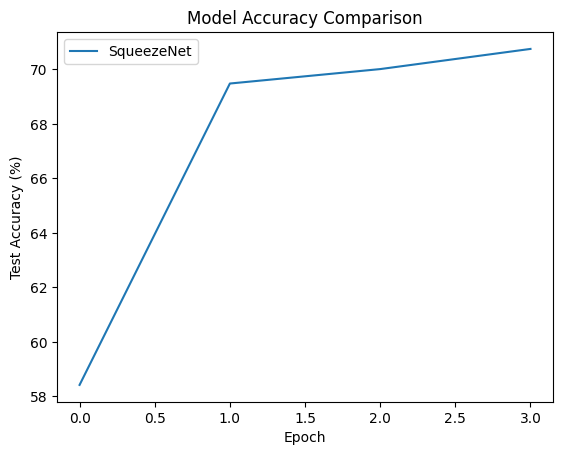

In [53]:
plot_accuracy("SqueezeNet",hist_sq)

### (b) Compare the VGG19 model’s performance with the previously created CNN. Give reasons for the superiority of the better performing model.

#### Here, we can see that the accuracy is given as 62.04%. This is way less compared to the previously created 3 Convolutional layer CNN. This could be due to the fact that we are only updating the fc layers and may be that the values are corrupted.

In [56]:
print(f"Accuracy of CNN with 3-Conv layers: {results['CNN-3'][3]}")
print(f"Accuracy of sQUEEZEnET model: {results['Squeeze'][3]}")

Accuracy of CNN with 3-Conv layers: 90.71
Accuracy of sQUEEZEnET model: 70.75
